# SigmaQuoridor Training Analysis
Plots for `training_stats.csv` and `eval_results.csv` produced by `train.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

MODEL_DIR = "models_7x7_v2"

stats_path = Path(MODEL_DIR) / "training_stats.csv"
eval_path  = Path(MODEL_DIR) / "eval_results.csv"

stats = pd.read_csv(stats_path) if stats_path.exists() else pd.DataFrame()
evals = pd.read_csv(eval_path)  if eval_path.exists()  else pd.DataFrame()

print(f"training_stats: {len(stats)} rows")
print(f"eval_results:   {len(evals)} rows")
if not evals.empty:
    print(f"Opponents: {evals['opponent'].unique().tolist()}")

training_stats: 137 rows
eval_results:   258 rows
Opponents: ['random', 'greedy', 'old-best   1s', 'old-best  50s', 'old-best 100s', 'old-best 200s', 'old-best 400s', 'old-best 800s', 'minimax d2', 'minimax d3']


## Training Losses

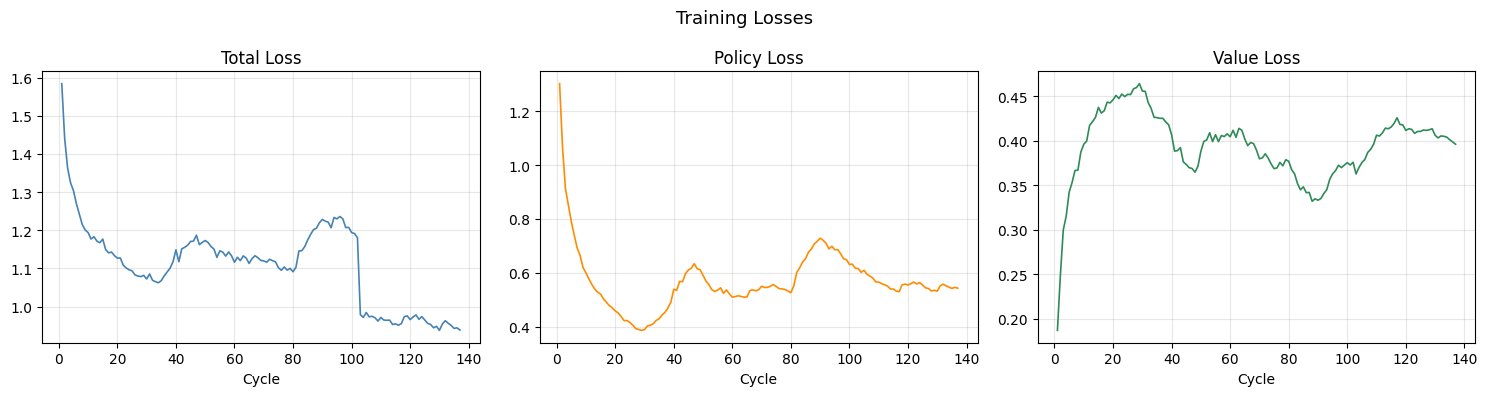

In [2]:
if stats.empty:
    print("No training_stats.csv found.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training Losses", fontsize=13)

    for ax, col, title, color in zip(
        axes,
        ["loss_total", "loss_policy", "loss_value"],
        ["Total Loss", "Policy Loss", "Value Loss"],
        ["steelblue", "darkorange", "seagreen"],
    ):
        if col in stats.columns:
            ax.plot(stats["cycle"], stats[col], color=color, linewidth=1.2)
            ax.set_title(title)
            ax.set_xlabel("Cycle")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Holdout Losses (Train vs Holdout)

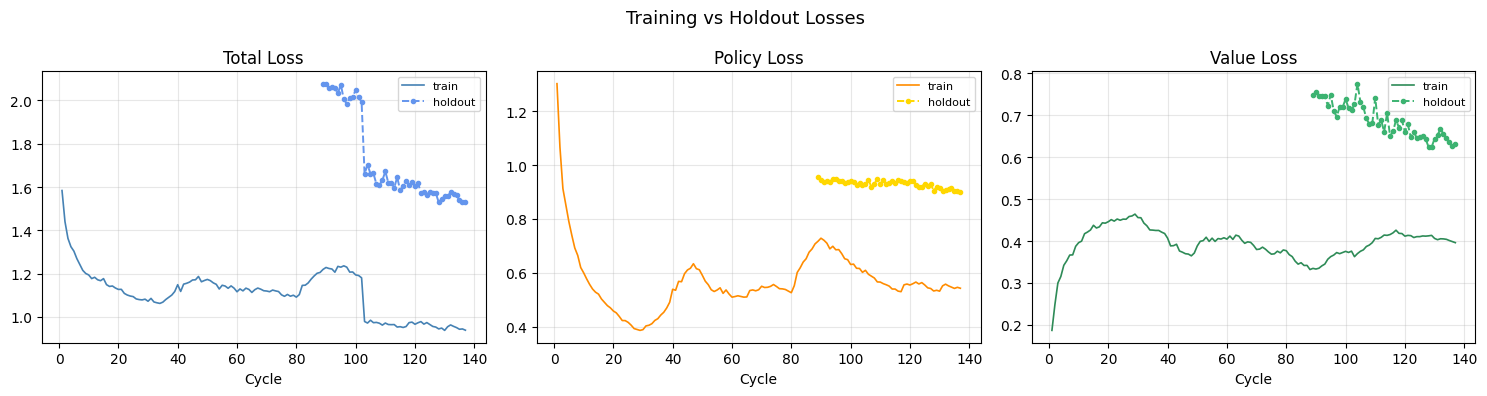

In [3]:
holdout_cols = ["holdout_loss_total", "holdout_loss_policy", "holdout_loss_value"]
train_cols   = ["loss_total",         "loss_policy",         "loss_value"]
titles       = ["Total Loss",          "Policy Loss",         "Value Loss"]
colors_train   = ["steelblue",   "darkorange", "seagreen"]
colors_holdout = ["cornflowerblue", "gold",    "mediumseagreen"]

if stats.empty:
    print("No data.")
elif not any(c in stats.columns for c in holdout_cols):
    print("No holdout loss columns found — run at least one training cycle with HOLDOUT_DIR set.")
else:
    # Only plot cycles that have at least one holdout value recorded
    has_holdout = stats[holdout_cols].apply(pd.to_numeric, errors="coerce").notna().any(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Training vs Holdout Losses", fontsize=13)

    for ax, tc, hc, title, ct, ch in zip(axes, train_cols, holdout_cols, titles,
                                          colors_train, colors_holdout):
        if tc in stats.columns:
            y_train = pd.to_numeric(stats[tc], errors="coerce")
            ax.plot(stats["cycle"], y_train,
                    color=ct, linewidth=1.2, label="train")
        if hc in stats.columns:
            y_hold = pd.to_numeric(stats.loc[has_holdout, hc], errors="coerce")
            ax.plot(stats.loc[has_holdout, "cycle"], y_hold,
                    color=ch, linewidth=1.4, linestyle="--", marker="o",
                    markersize=3, label="holdout")
        ax.set_title(title)
        ax.set_xlabel("Cycle")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [4]:
all_loss_cols = ["cycle", "loss_total", "loss_policy", "loss_value",
                 "holdout_loss_total", "holdout_loss_policy", "holdout_loss_value"]
present_cols = [c for c in all_loss_cols if c in stats.columns]
loss_table = stats[present_cols].copy()
for c in present_cols[1:]:
    loss_table[c] = pd.to_numeric(loss_table[c], errors="coerce")
loss_table.tail(20).style \
    .format({c: "{:.4f}" for c in present_cols if c != "cycle"}, na_rep="—") \
    .set_caption("Last 20 cycles — training vs holdout losses") \
    .background_gradient(subset=[c for c in present_cols if c != "cycle"], cmap="RdYlGn_r", axis=0)


,cycle,loss_total,loss_policy,loss_value,holdout_loss_total,holdout_loss_policy,holdout_loss_value
117,118,0.9736,0.5552,0.4184,1.6073,0.9367,0.6705
118,119,0.9759,0.5580,0.4178,1.6214,0.9337,0.6878
119,120,0.9661,0.5544,0.4117,1.6034,0.9428,0.6607
120,121,0.9729,0.5594,0.4135,1.6190,0.9409,0.6781
121,122,0.9783,0.5654,0.4129,1.5737,0.9266,0.6471
122,123,0.9667,0.5584,0.4084,1.5791,0.9182,0.6609
123,124,0.9738,0.5633,0.4105,1.5654,0.9201,0.6453
124,125,0.9650,0.5545,0.4105,1.5789,0.9317,0.6472
125,126,0.9560,0.5439,0.4121,1.5739,0.9242,0.6497
126,127,0.9532,0.5415,0.4117,1.5731,0.9300,0.6431


## Value Accuracy & Policy Entropy

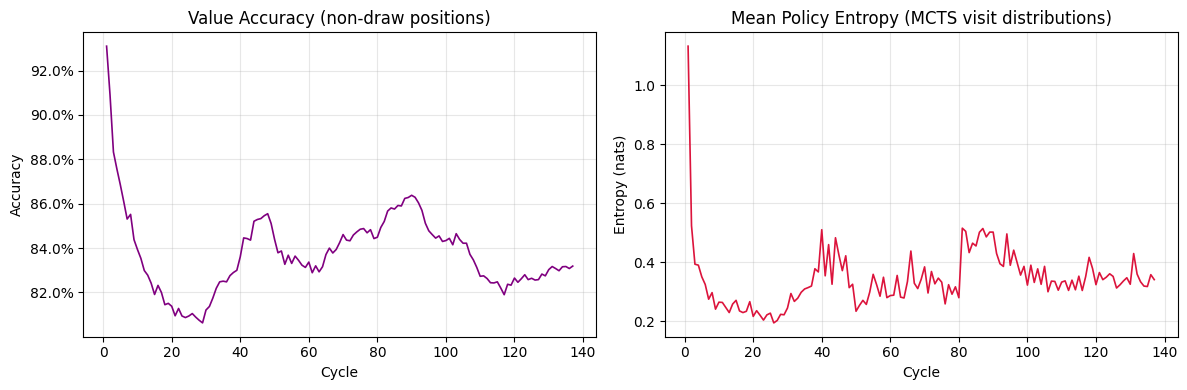

In [5]:
if stats.empty:
    print("No data.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if "value_accuracy" in stats.columns:
        ax1.plot(stats["cycle"], stats["value_accuracy"], color="purple", linewidth=1.2)
        ax1.set_title("Value Accuracy (non-draw positions)")
        ax1.set_xlabel("Cycle")
        ax1.set_ylabel("Accuracy")
        ax1.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
        ax1.grid(True, alpha=0.3)

    if "mean_policy_entropy" in stats.columns:
        ax2.plot(stats["cycle"], stats["mean_policy_entropy"], color="crimson", linewidth=1.2)
        ax2.set_title("Mean Policy Entropy (MCTS visit distributions)")
        ax2.set_xlabel("Cycle")
        ax2.set_ylabel("Entropy (nats)")
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Self-Play Outcomes & Game Length

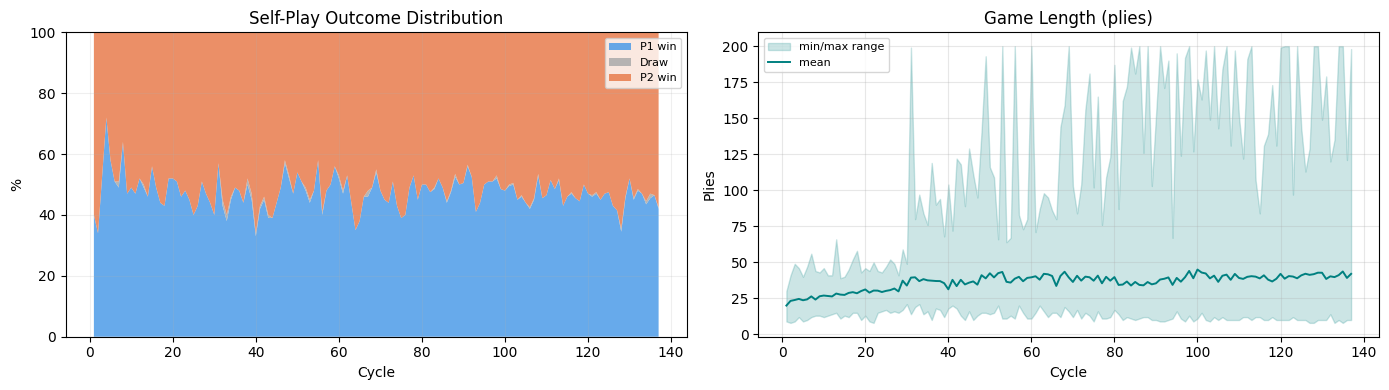

In [6]:
if stats.empty:
    print("No data.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Win rates as stacked area
    if all(c in stats.columns for c in ["p1_wins", "p2_wins", "draws"]):
        total = stats["p1_wins"] + stats["p2_wins"] + stats["draws"]
        p1_r  = stats["p1_wins"] / total * 100
        p2_r  = stats["p2_wins"] / total * 100
        dr_r  = stats["draws"]   / total * 100
        ax1.stackplot(stats["cycle"], p1_r, dr_r, p2_r,
                      labels=["P1 win", "Draw", "P2 win"],
                      colors=["#4c9be8", "#aaaaaa", "#e87c4c"], alpha=0.85)
        ax1.set_title("Self-Play Outcome Distribution")
        ax1.set_xlabel("Cycle")
        ax1.set_ylabel("%")
        ax1.legend(loc="upper right", fontsize=8)
        ax1.set_ylim(0, 100)
        ax1.grid(True, alpha=0.2)

    # Game length
    if all(c in stats.columns for c in ["mean_game_length", "min_game_length", "max_game_length"]):
        ax2.fill_between(stats["cycle"], stats["min_game_length"], stats["max_game_length"],
                         alpha=0.2, color="teal", label="min/max range")
        ax2.plot(stats["cycle"], stats["mean_game_length"], color="teal", linewidth=1.4, label="mean")
        ax2.set_title("Game Length (plies)")
        ax2.set_xlabel("Cycle")
        ax2.set_ylabel("Plies")
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Walls Placed Per Game

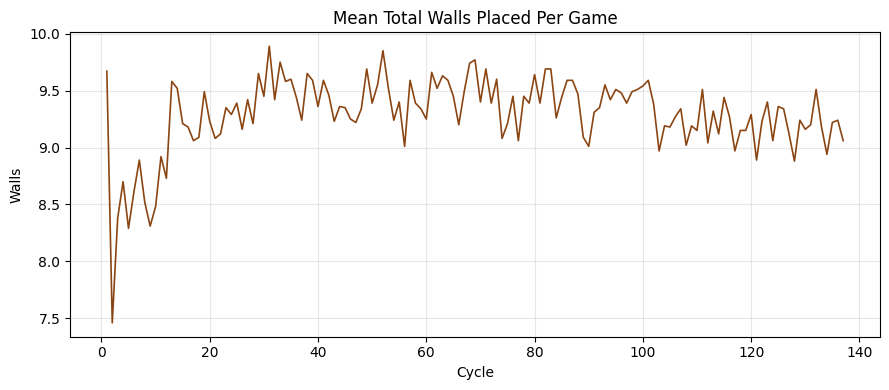

In [7]:
if stats.empty or "mean_walls_placed" not in stats.columns:
    print("No data.")
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(stats["cycle"], stats["mean_walls_placed"], color="saddlebrown", linewidth=1.2)
    ax.set_title("Mean Total Walls Placed Per Game")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Walls")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Evaluation Win% vs Opponents Over Training

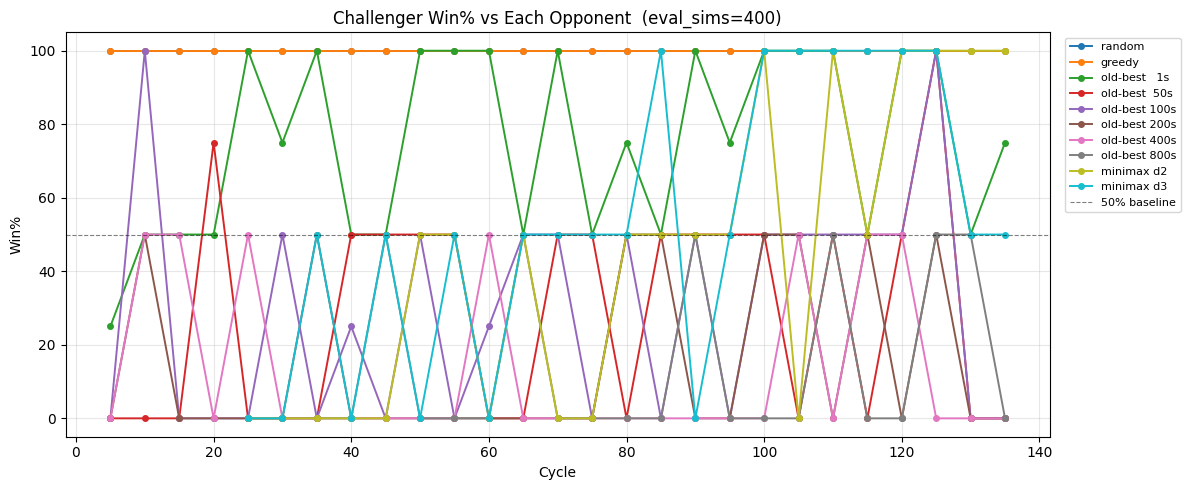

In [8]:
if evals.empty:
    print("No eval_results.csv found.")
else:
    evals["win_pct"] = pd.to_numeric(evals["win_pct"], errors="coerce")
    opponents = evals["opponent"].unique()

    fig, ax = plt.subplots(figsize=(12, 5))
    cmap = plt.get_cmap("tab10")

    for i, opp in enumerate(opponents):
        df = evals[evals["opponent"] == opp].sort_values("cycle")
        ax.plot(df["cycle"], df["win_pct"], marker="o", markersize=4,
                label=opp, color=cmap(i % 10), linewidth=1.4)

    ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="50% baseline")
    ax.set_title(f"Challenger Win% vs Each Opponent  (eval_sims={evals['eval_sims'].iloc[0] if 'eval_sims' in evals.columns else '?'})")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Win%")
    ax.set_ylim(-5, 105)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Evaluation P1 vs P2 Win Rate (per opponent)

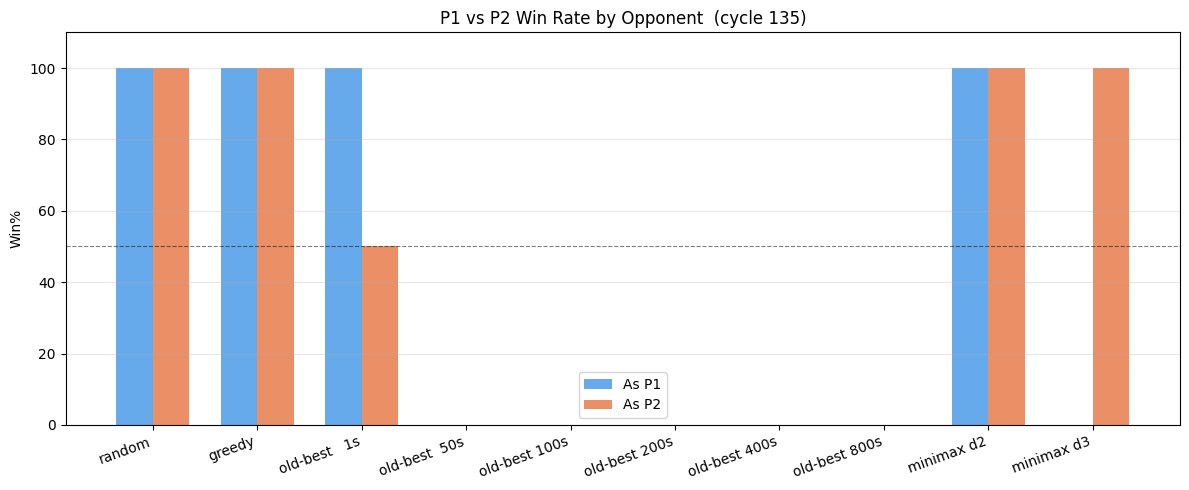

In [9]:
if evals.empty:
    print("No data.")
else:
    # Use most recent eval cycle for the bar chart
    latest_cycle = evals["cycle"].max()
    latest = evals[evals["cycle"] == latest_cycle].copy()

    latest["win_pct_p1"] = np.where(
        latest["n_as_p1"] > 0,
        (latest["w_as_p1"] + 0.5 * latest["d_as_p1"]) / latest["n_as_p1"] * 100,
        np.nan,
    )
    latest["win_pct_p2"] = np.where(
        latest["n_as_p2"] > 0,
        (latest["w_as_p2"] + 0.5 * latest["d_as_p2"]) / latest["n_as_p2"] * 100,
        np.nan,
    )

    x = np.arange(len(latest))
    w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w/2, latest["win_pct_p1"], w, label="As P1", color="#4c9be8", alpha=0.85)
    ax.bar(x + w/2, latest["win_pct_p2"], w, label="As P2", color="#e87c4c", alpha=0.85)
    ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(latest["opponent"], rotation=20, ha="right")
    ax.set_ylabel("Win%")
    ax.set_ylim(0, 110)
    ax.set_title(f"P1 vs P2 Win Rate by Opponent  (cycle {latest_cycle})")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Hyperparameter Changes Over Training

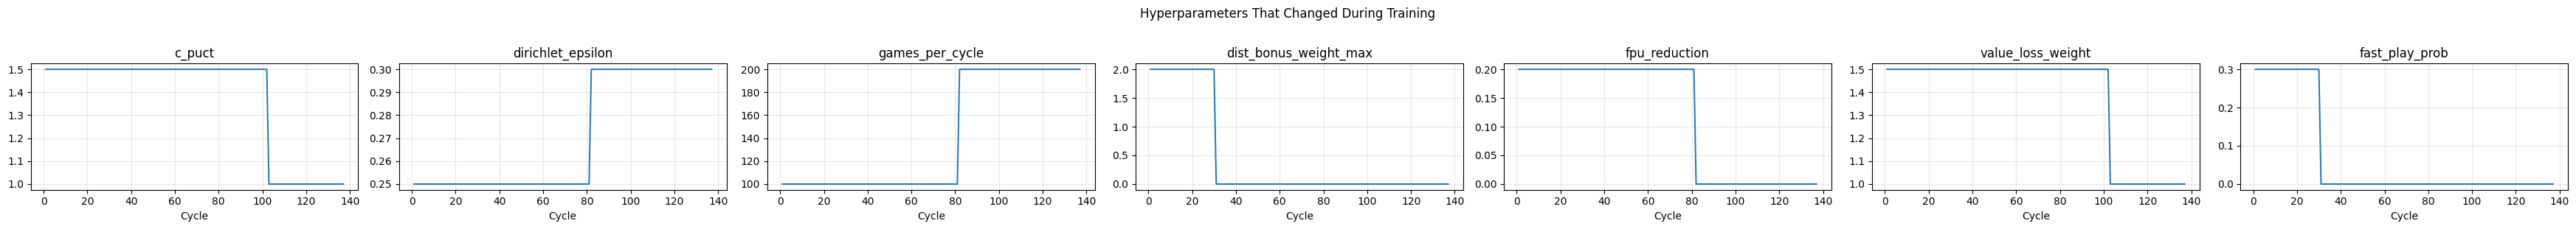

In [10]:
if stats.empty:
    print("No data.")
else:
    # Show only columns that actually changed during the run
    hp_cols = [
        "lr", "c_puct", "dirichlet_alpha", "dirichlet_epsilon",
        "mcts_sims", "games_per_cycle", "batch_size",
        "dist_bonus_weight_max", "fpu_reduction", "value_loss_weight",
        "buffer_recency_decay", "fast_play_prob",
    ]
    present = [c for c in hp_cols if c in stats.columns]
    changed = [c for c in present if stats[c].nunique() > 1]

    if not changed:
        print("No hyperparameters changed during this run.")
        print("\nCurrent values:")
        for c in present:
            print(f"  {c:30s} = {stats[c].iloc[-1]}")
    else:
        fig, axes = plt.subplots(1, len(changed), figsize=(5 * len(changed), 3))
        if len(changed) == 1:
            axes = [axes]
        for ax, col in zip(axes, changed):
            ax.plot(stats["cycle"], stats[col], linewidth=1.4)
            ax.set_title(col)
            ax.set_xlabel("Cycle")
            ax.grid(True, alpha=0.3)
        plt.suptitle("Hyperparameters That Changed During Training", y=1.02)
        plt.tight_layout()
        plt.show()

## Holdout validation losses — models_7x7/checkpoints

In [2]:
import sys, importlib
sys.path.insert(0, ".")
import numpy as np
import torch
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Re-import project modules (safe if kernel already has them)
import train as _train_mod
importlib.reload(_train_mod)
from train import load_holdout, compute_holdout_loss
from dual_network import load_model

# ── Config ────────────────────────────────────────────────────────────────────
CKPT_DIR      = Path("models_7x7/checkpoints")
DATA_DIR      = "data_7x7"
HOLDOUT_CYCLES = 20
HOLDOUT_SIZE   = 4096 * 100
BATCH_SIZE     = 4096
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Build fixed holdout set ───────────────────────────────────────────────────
holdout = load_holdout(DATA_DIR, HOLDOUT_CYCLES, HOLDOUT_SIZE, seed=42)
if holdout is None:
    raise RuntimeError(f"No data found in {DATA_DIR}")
states, policies, values = holdout
print(f"Holdout set: {len(states):,} positions")

# ── Evaluate every checkpoint ─────────────────────────────────────────────────
checkpoints = sorted(CKPT_DIR.glob("cycle_*.pt"))
results = []  # list of (cycle_idx, total, policy, value)

for ckpt in tqdm(checkpoints, desc="evaluating checkpoints"):
    cycle_idx = int(ckpt.stem.split("_")[1])
    model = load_model(str(ckpt), device=DEVICE)
    losses = compute_holdout_loss(model, states, policies, values, DEVICE, BATCH_SIZE)
    results.append((cycle_idx, losses["total"], losses["policy"], losses["value"]))
    del model
    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

results.sort()
cycles   = [r[0] for r in results]
l_total  = [r[1] for r in results]
l_policy = [r[2] for r in results]
l_value  = [r[3] for r in results]

Device: cuda
Holdout set: 409,600 positions


evaluating checkpoints: 100%|██████████| 15/15 [00:22<00:00,  1.50s/it]


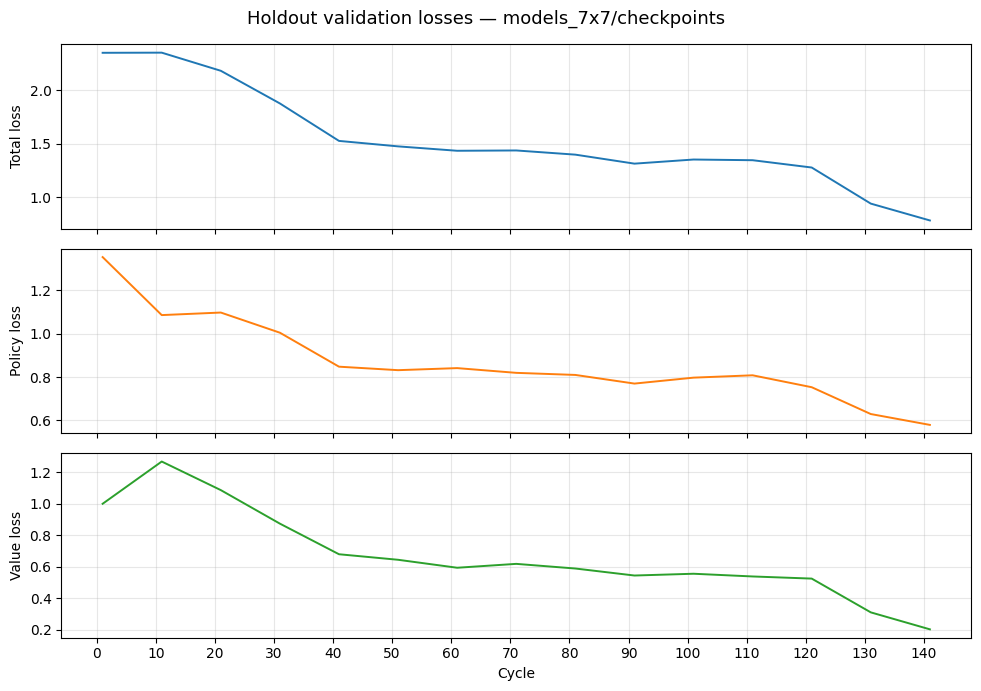

In [4]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Holdout validation losses — models_7x7/checkpoints", fontsize=13)

specs = [
    (axes[0], l_total,  "Total loss",  "tab:blue"),
    (axes[1], l_policy, "Policy loss", "tab:orange"),
    (axes[2], l_value,  "Value loss",  "tab:green"),
]
for ax, data, title, color in specs:
    ax.plot(cycles, data, color=color, linewidth=1.4)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))

axes[2].set_xlabel("Cycle", fontsize=10)
plt.tight_layout()
plt.show()

## P1 / P2 Advantage Analysis (Tournament Data)

All 5130 games:
  P1 score%: 51.7%  (wins 2643, draws 19, losses 2468)

P1 score% by matchup tier:
  top 4 (rank 1–4)            : 56.67%  (180 games)
  top 9 (rank 1–9)            : 57.27%  (1080 games)
  top 13 (rank 1–13)          : 54.76%  (2340 games)
  all agents                  : 51.71%  (5130 games)

Top-9 symmetric pairs: mean P1 score% = 57.27%  (n=36 pairs, min=10.0%, max=100.0%)


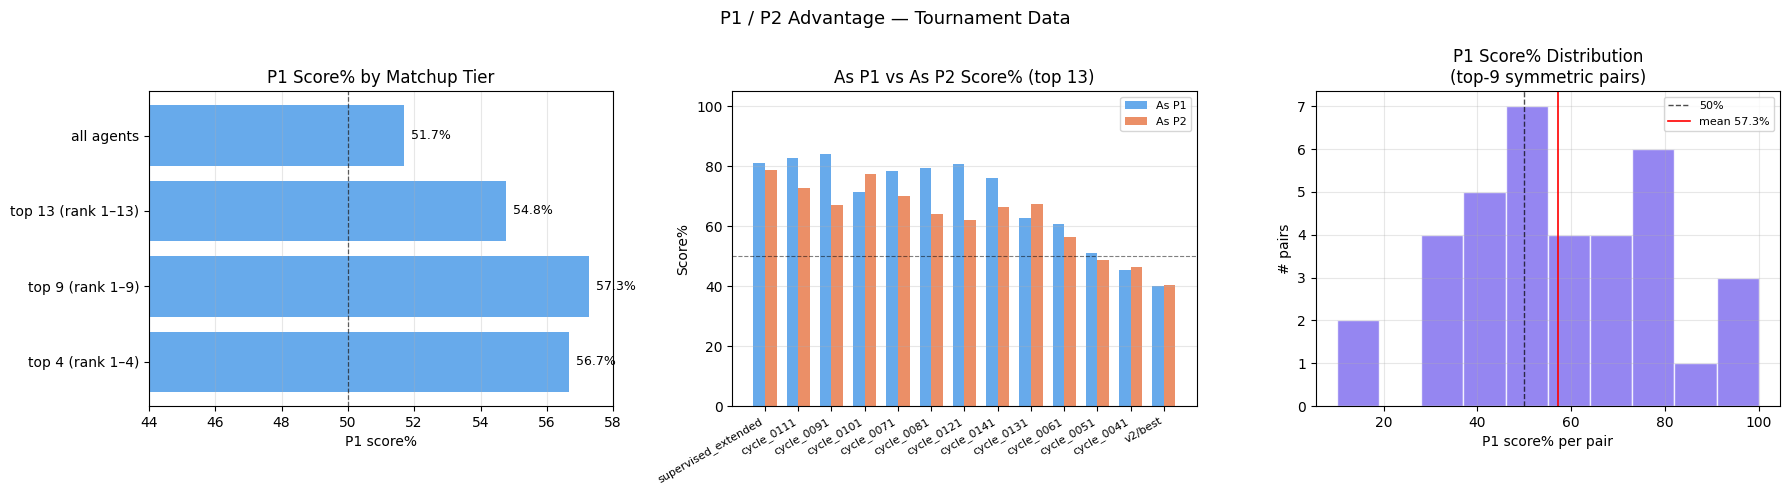

In [3]:
import csv, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

MATCHUPS_CSV = "models_7x7/checkpoints/tournament_results_matchups.csv"

with open(MATCHUPS_CSV, newline="") as f:
    rows = list(csv.DictReader(f))

# Elo-ranked agents (best first)
elo_order = [
    "models_7x7\\supervised_extended.pt",
    "cycle_0111", "cycle_0091", "cycle_0101", "cycle_0071",
    "cycle_0081", "cycle_0121", "cycle_0141", "cycle_0131",
    "cycle_0061", "cycle_0051", "cycle_0041",
    "models_7x7_v2\\best.pt",
    "cycle_0031", "minimax-3", "minimax-2",
    "cycle_0021", "cycle_0011", "cycle_0001",
]
lbl = {n: n.replace("models_7x7\\", "").replace("models_7x7_v2\\", "v2/").replace(".pt", "")
       for n in elo_order}

# ── 1. Overall P1 win rate (all games) ───────────────────────────────────────
total = len(rows)
p1_wins  = sum(1 for r in rows if r["result"] == "p1_win")
p2_wins  = sum(1 for r in rows if r["result"] == "p2_win")
draws    = sum(1 for r in rows if r["result"] == "draw")
p1_score = (p1_wins + 0.5 * draws) / total * 100

print(f"All {total} games:")
print(f"  P1 score%: {p1_score:.1f}%  (wins {p1_wins}, draws {draws}, losses {p2_wins})")

# ── 2. Top-N tier filter ──────────────────────────────────────────────────────
top_n_sets = {
    "top 4 (rank 1–4)":   set(elo_order[:4]),
    "top 9 (rank 1–9)":   set(elo_order[:9]),
    "top 13 (rank 1–13)": set(elo_order[:13]),
    "all agents":          set(elo_order),
}

print("\nP1 score% by matchup tier:")
tier_labels, tier_p1 = [], []
for tier_name, agent_set in top_n_sets.items():
    tier_rows = [r for r in rows if r["player1"] in agent_set and r["player2"] in agent_set]
    if not tier_rows:
        continue
    t = len(tier_rows)
    w = sum(1 for r in tier_rows if r["result"] == "p1_win")
    d = sum(1 for r in tier_rows if r["result"] == "draw")
    p = (w + 0.5 * d) / t * 100
    print(f"  {tier_name:28s}: {p:.2f}%  ({t} games)")
    tier_labels.append(tier_name)
    tier_p1.append(p)

# ── 3. Per-agent P1 vs P2 performance (top 13) ───────────────────────────────
agents_shown = elo_order[:13]
p1_rates, p2_rates, agent_lbls = [], [], []

for agent in agents_shown:
    as_p1 = [r for r in rows if r["player1"] == agent]
    as_p2 = [r for r in rows if r["player2"] == agent]
    if not as_p1 or not as_p2:
        continue
    p1_r = (sum(1 for r in as_p1 if r["result"] == "p1_win")
            + 0.5 * sum(1 for r in as_p1 if r["result"] == "draw")) / len(as_p1) * 100
    p2_r = (sum(1 for r in as_p2 if r["result"] == "p2_win")
            + 0.5 * sum(1 for r in as_p2 if r["result"] == "draw")) / len(as_p2) * 100
    p1_rates.append(p1_r)
    p2_rates.append(p2_r)
    agent_lbls.append(lbl[agent])

# ── 4. P1 advantage per symmetric pair (same agents, both colours played) ─────
# For each ordered pair (i<j), collect P1 score across both colour assignments
pair_p1 = {}
pair_counts = {}
for row in rows:
    key = tuple(sorted([row["player1"], row["player2"]]))
    pair_p1.setdefault(key, 0.0)
    pair_counts.setdefault(key, 0)
    pair_p1[key]    += 1.0 if row["result"] == "p1_win" else (0.5 if row["result"] == "draw" else 0.0)
    pair_counts[key] += 1

# Restrict to top-9 vs top-9 pairs with >= 10 games
top9 = set(elo_order[:9])
top_pairs = {k: pair_p1[k] / pair_counts[k] * 100
             for k in pair_p1
             if k[0] in top9 and k[1] in top9 and pair_counts[k] >= 10}

pair_p1_values = list(top_pairs.values())
print(f"\nTop-9 symmetric pairs: mean P1 score% = {np.mean(pair_p1_values):.2f}%  "
      f"(n={len(pair_p1_values)} pairs, "
      f"min={min(pair_p1_values):.1f}%, max={max(pair_p1_values):.1f}%)")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("P1 / P2 Advantage — Tournament Data", fontsize=13)

# Panel 1: tier bar chart
ax = axes[0]
colors = ["#4c9be8" if v > 50 else "#e87c4c" for v in tier_p1]
bars = ax.barh(tier_labels, tier_p1, color=colors, alpha=0.85)
ax.axvline(50, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
ax.set_xlabel("P1 score%")
ax.set_title("P1 Score% by Matchup Tier")
ax.set_xlim(44, 58)
for bar, val in zip(bars, tier_p1):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.grid(True, axis="x", alpha=0.3)

# Panel 2: per-agent P1 vs P2 win rate
ax = axes[1]
x = np.arange(len(agent_lbls))
w = 0.35
ax.bar(x - w/2, p1_rates, w, label="As P1", color="#4c9be8", alpha=0.85)
ax.bar(x + w/2, p2_rates, w, label="As P2", color="#e87c4c", alpha=0.85)
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(agent_lbls, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Score%")
ax.set_ylim(0, 105)
ax.set_title("As P1 vs As P2 Score% (top 13)")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# Panel 3: distribution of P1 score% across top-9 symmetric pairs
ax = axes[2]
ax.hist(pair_p1_values, bins=10, color="#7b68ee", alpha=0.8, edgecolor="white")
ax.axvline(50, color="black", linestyle="--", linewidth=1.0, alpha=0.7, label="50%")
ax.axvline(np.mean(pair_p1_values), color="red", linestyle="-", linewidth=1.2,
           label=f"mean {np.mean(pair_p1_values):.1f}%")
ax.set_xlabel("P1 score% per pair")
ax.set_ylabel("# pairs")
ax.set_title("P1 Score% Distribution\n(top-9 symmetric pairs)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
